# Item Classification using ItemClassifier

This notebook demonstrates the rule-based `ItemClassifier` approach which categorizes items into:
- **Representative**: Similar statistical properties to the subcategory average
- **Independent**: High sales but different behavior than subcategory
- **Small**: Low but meaningful sales
- **Irrelevant**: Very low sales, minimal impact

In [1]:
import pyarrow.feather as feather
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from item_classifier import *
from plots import *

## Load Data

In [2]:
table = feather.read_table('../dataset/data_andre.feather', memory_map=True)
df = table.to_pandas()
df.head()

,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
0,2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
1,2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2,2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
3,2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
4,2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


## Prepare Data with DatetimeIndex

In [3]:
df_indexed = df.copy()
df_indexed["date"] = pd.to_datetime(df_indexed["date"])
df_indexed = df_indexed.set_index("date").sort_index()
df_indexed.head()

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


## ItemClassifier Approach

The `ItemClassifier` uses rule-based logic comparing each item to subcategory-level statistics:

### Classification Rules

1. **Representative**: `sum(sales) > w3*B` AND similar mean/std/amplitude to subcategory
2. **Irrelevant**: `sum(sales) < w1*B` AND `max(sales) < w2*C`
3. **Small**: `w1*B <= sum(sales) <= w3*B`
4. **Independent**: Everything else (high sales but different behavior)

### Calibration Parameters

The function auto-calibrates `scat_ABC` and `scat_stats` from your data:
- `scat_ABC = (A, B, C)`: quantiles of total_sales and max_sales across items
- `scat_stats = (mean, std, amp)`: median/mean statistics across items

### Weights (defaults in ItemClassifier)
- `w1 = 0.1`: irrelevant sales threshold
- `w2 = 1.0`: irrelevant max threshold
- `w3 = 0.5`: small/representative boundary
- `max_dist = 0.5`: closeness tolerance for "representative" (max/min factor ratio <= 1.5)

## Classify Items

In [4]:
# Classify using ItemClassifier approach
df_classified, labels_df, summary = classify_items_item_classifier(
    df_indexed,
    date_col=None,  # Use DatetimeIndex
    agg_per_date=None,  # No duplicate dates expected
    # Calibration quantiles (adjust if needed)
    a_quantile=0.80,
    b_quantile=0.50,
    c_quantile=0.50,
    stats_agg="median"  # "median" or "mean"
)

print("\n" + "="*70)
print("ITEM CLASSIFICATION SUMMARY")
print("="*70)
print(f"Total items classified: {summary['total_items']}")
print("\nLabel Distribution:")
for label, count in summary['label_counts'].items():
    pct = 100 * count / summary['total_items']
    print(f"  {label:15s}: {count:4d} items ({pct:5.1f}%)")




ITEM CLASSIFICATION SUMMARY
Total items classified: 1427

Label Distribution:
  representative : 1005 items ( 70.4%)
  independent    :  318 items ( 22.3%)
  small          :  104 items (  7.3%)


## Inspect Labeled Data

In [5]:
# Show the labeled dataframe
df_classified.head(20)

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,independent
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,1,0.0,6269,representative
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative
2021-01-23,102689,3,sprd btr mrgrn,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative
2021-01-23,20404,6,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative
2021-01-23,606214,30,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,independent
2021-01-23,950488,4,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative


In [6]:
# Show per-item summary
labels_df.head(10)

,item_id,label,n_obs,total_sales,mean_sales,std_sales,max_sales,amp_sales
0,27,independent,761,8421.0,11.065703,5.683160,31.0,31.0
1,952568,representative,761,3920.0,5.151117,4.376616,28.0,28.0
2,809,representative,761,3063.0,4.024967,3.374932,18.0,18.0
3,20405,representative,760,2710.0,3.565789,3.387707,25.0,25.0
4,605573,representative,761,3709.0,4.873850,3.468636,19.0,19.0
5,102689,representative,761,2181.0,2.865966,2.680909,18.0,18.0
6,20404,representative,756,2150.0,2.843915,2.824580,18.0,18.0
7,606214,independent,761,17580.0,23.101183,8.609451,53.0,53.0
8,950488,representative,760,2288.0,3.010526,3.261933,21.0,21.0
9,20253,independent,760,1881.0,2.475000,1.899839,9.0,9.0


## Visualizations


Detailed Classification Distribution:
Total items: 1427

Breakdown:
  representative:   1005 items ( 70.4%)
  independent :    318 items ( 22.3%)
  small       :    104 items (  7.3%)


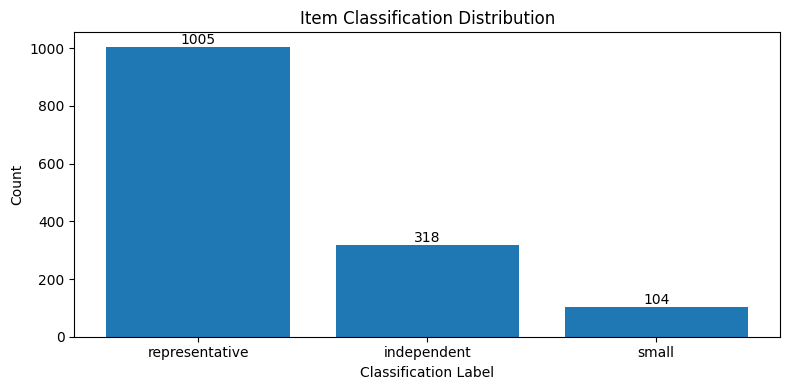

In [7]:
# Plot label distribution
plot_label_distribution(summary['label_counts']);

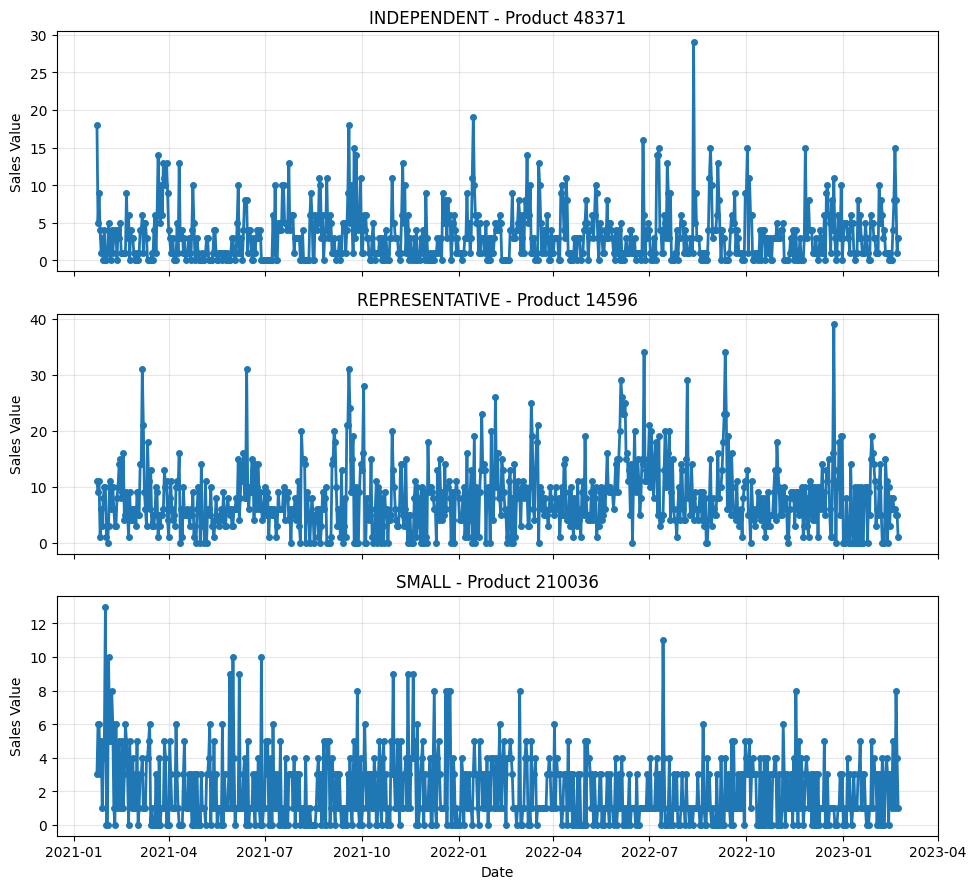

In [8]:
# Plot random samples per label
plot_random_sample_per_label(df_indexed, df_classified, date_col=None, seed=42);

Product ID: 27
Date range: 2021-01-23 00:00:00 to 2023-02-22 00:00:00
Total records: 761
Non-zero sales: 755


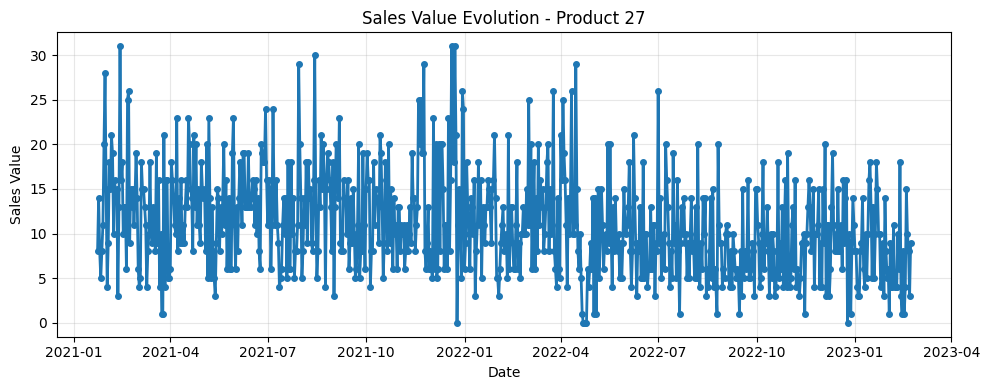

(<Axes: title={'center': 'Sales Value Evolution - Product 27'}, xlabel='Date', ylabel='Sales Value'>,
           date  value
 0   2021-01-23      8
 1   2021-01-24     14
 2   2021-01-25      8
 3   2021-01-26      5
 4   2021-01-27      8
 ..         ...    ...
 756 2023-02-18     15
 757 2023-02-19     10
 758 2023-02-20      8
 759 2023-02-21      3
 760 2023-02-22      9
 
 [761 rows x 2 columns],
 {'product_id': np.int64(27),
  'date_min': Timestamp('2021-01-23 00:00:00'),
  'date_max': Timestamp('2023-02-22 00:00:00'),
  'total_records': 761,
  'non_zero_sales': 755,
  'describe': count    761.000000
  mean      11.065703
  std        5.683160
  min        0.000000
  25%        6.000000
  50%       10.000000
  75%       15.000000
  max       31.000000
  Name: value, dtype: float64})

In [9]:
# Example: plot a specific item (adjust item_id as needed)
sample_item = labels_df.iloc[0]['item_id']
plot_product_value_evolution(df_indexed, selected_product=sample_item, date_col=None, value_col='value')

## Filter Specific Labels

In [10]:
# Show only representative items
representative_items = df_classified[df_classified['item_label'] == 'representative']
print(f"Representative items: {len(representative_items['item_id'].unique())}")
representative_items.head()

Representative items: 1005


,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,1,0.0,6269,representative
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative
2021-01-23,102689,3,sprd btr mrgrn,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,representative


In [11]:
# Show only independent items (high sales, different behavior)
independent_items = df_classified[df_classified['item_label'] == 'independent']
print(f"Independent items: {len(independent_items['item_id'].unique())}")
independent_items.head()

Independent items: 318


,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,independent
2021-01-23,606214,30,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,independent
2021-01-23,20253,6,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,independent
2021-01-23,606230,28,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,independent
2021-01-23,606279,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,independent


## Per-Label Statistics

In [12]:
# Display summary statistics per label
stats_df = pd.DataFrame(summary['summary_stats'])
print("\nSummary Statistics by Label:")
print(stats_df.to_string(index=False))


Summary Statistics by Label:
         label  n_obs_mean  n_obs_min  n_obs_max  total_sales_mean  total_sales_min  total_sales_max  mean_sales_mean  mean_sales_min  mean_sales_max  std_sales_mean  std_sales_min  std_sales_max  max_sales_mean  max_sales_min  max_sales_max  amp_sales_mean  amp_sales_min  amp_sales_max
   independent  757.418239        569        761       8685.449686           1618.0         125015.0        11.457028        2.128947      164.277267        7.151677       1.899839      64.757468       58.858491            9.0         1000.0       58.858491            9.0         1000.0
representative  758.803980        591        761       3983.273632           1601.0          45982.0         5.248123        2.103811       60.423127        4.351628       1.905751      58.123074       27.433831            9.0          328.0       27.433831            9.0          328.0
         small  758.788462        674        761       1431.865385           1034.0           1594.0      

In [13]:
'''

# Example: create classifier with custom weights
custom_classifier = ItemClassifier()
custom_classifier.set_weights(
    w1=0.05,  # stricter irrelevant threshold
    w2=1.0,
    w3=0.6,   # wider "small" range
    max_dist=0.3  # tighter representative tolerance
)

# Classify with custom weights
df_custom, labels_custom, summary_custom = classify_items_item_classifier(
    df_indexed,
    classifier=custom_classifier,
    date_col=None
)

print("\nCustom Classifier Results:")
for label, count in summary_custom['label_counts'].items():
    pct = 100 * count / summary_custom['total_items']
    print(f"  {label:15s}: {count:4d} items ({pct:5.1f}%)")

    '''

'\n\n# Example: create classifier with custom weights\ncustom_classifier = ItemClassifier()\ncustom_classifier.set_weights(\n    w1=0.05,  # stricter irrelevant threshold\n    w2=1.0,\n    w3=0.6,   # wider "small" range\n    max_dist=0.3  # tighter representative tolerance\n)\n\n# Classify with custom weights\ndf_custom, labels_custom, summary_custom = classify_items_item_classifier(\n    df_indexed,\n    classifier=custom_classifier,\n    date_col=None\n)\n\nprint("\nCustom Classifier Results:")\nfor label, count in summary_custom[\'label_counts\'].items():\n    pct = 100 * count / summary_custom[\'total_items\']\n    print(f"  {label:15s}: {count:4d} items ({pct:5.1f}%)")\n\n    '

In [14]:
'''
# Also run ADI/CV classification
df_adi_cv, labels_adi_cv, summary_adi_cv = classify_items_adi_cv(df_indexed)

# Merge labels for comparison
comparison = labels_df[['item_id', 'label']].rename(columns={'label': 'ic_label'})
comparison = comparison.merge(
    labels_adi_cv[['item_id', 'label']].rename(columns={'label': 'adi_cv_label'}),
    on='item_id'
)

print("\nLabel Comparison (ItemClassifier vs ADI/CV):")
comparison_matrix = pd.crosstab(comparison['ic_label'], comparison['adi_cv_label'])
print(comparison_matrix)
'''

'\n# Also run ADI/CV classification\ndf_adi_cv, labels_adi_cv, summary_adi_cv = classify_items_adi_cv(df_indexed)\n\n# Merge labels for comparison\ncomparison = labels_df[[\'item_id\', \'label\']].rename(columns={\'label\': \'ic_label\'})\ncomparison = comparison.merge(\n    labels_adi_cv[[\'item_id\', \'label\']].rename(columns={\'label\': \'adi_cv_label\'}),\n    on=\'item_id\'\n)\n\nprint("\nLabel Comparison (ItemClassifier vs ADI/CV):")\ncomparison_matrix = pd.crosstab(comparison[\'ic_label\'], comparison[\'adi_cv_label\'])\nprint(comparison_matrix)\n'

In [15]:
# Compute zero-sales rate for each item
zero_sales_stats = df_indexed.groupby('item_id')['value'].agg([
    ('total_obs', 'count'),
    ('zero_count', lambda x: (x == 0).sum()),
    ('zero_rate', lambda x: (x == 0).sum() / len(x))
]).reset_index()
# Filter by item label (e.g., representative/independent/small)
filter_field = "label"
filter_values = ["independent"]  # adjust as needed

zero_sales_stats = zero_sales_stats.merge(
    labels_df[["item_id", "label"]],
    on="item_id",
    how="left"
)
zero_sales_stats = zero_sales_stats[zero_sales_stats[filter_field].isin(filter_values)]


# Optionally also filter by max zero rate
max_zero_rate = 1.0
zero_sales_stats = zero_sales_stats[zero_sales_stats["zero_rate"] <= max_zero_rate]
# Sort by zero_rate ascending (lower is better)
zero_sales_stats = zero_sales_stats.sort_values('zero_rate')

zero_sales_stats


,item_id,total_obs,zero_count,zero_rate,label
1343,909293,761,2,0.002628,independent
1354,915640,761,2,0.002628,independent
1340,907969,761,2,0.002628,independent
1365,921558,761,2,0.002628,independent
1363,921516,761,2,0.002628,independent
...,...,...,...,...,...
617,89149,759,256,0.337286,independent
432,53667,761,259,0.340342,independent
1045,256207,761,260,0.341656,independent
366,30753,761,260,0.341656,independent


In [16]:
# Select top-k items with lowest zero rate
k = 1000 
top_k_items = zero_sales_stats.head(k)['item_id'].tolist()

# Create subset dataframe with only top-k items
df_top_k = df_indexed[df_indexed['item_id'].isin(top_k_items)].copy()

df_top_k

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,606214,30,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,20253,6,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0736,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,606230,28,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,606279,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-22,502330,1,new age bevs,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2023-02-22,505414,5,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2023-02-22,514230,18,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [17]:
independent_items.to_feather(path="../dataset/independent_items.feather")

In [18]:
representative_items.to_feather(path="../dataset/representative_items.feather")

In [19]:
df_top_k.to_feather(path="../dataset/subset_set_graph.feather")

In [20]:
df_top_k['labels'] = df_top_k['item_id'].map(labels_df.set_index('item_id')['label'])


In [21]:
df_top_k['labels'].value_counts()

labels
independent    240859
Name: count, dtype: int64

In [ ]:
df_classified[df_classified["item_id"] == 916110]

,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
1203,2021-01-23,916110,60,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
1976,2021-01-24,916110,29,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
2683,2021-01-25,916110,5,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
5133,2021-01-26,916110,13,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
6052,2021-01-27,916110,31,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077254,2023-02-18,916110,41,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
1078076,2023-02-19,916110,35,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
1079162,2023-02-20,916110,23,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
1080804,2023-02-21,916110,25,eggs egg substitutes,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
